In [1]:
import torch

import triton
import triton.language as tl

DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [2]:
@triton.autotune(
    configs=[
        triton.Config({'BLOCK_SIZE': 1024}, num_warps=4, num_stages=2),
        triton.Config({'BLOCK_SIZE': 2048}, num_warps=8, num_stages=2),
        triton.Config({'BLOCK_SIZE': 4096}, num_warps=8, num_stages=2),
        triton.Config({'BLOCK_SIZE': 4096}, num_warps=16, num_stages=2),
    ],
    key=['n_cols'],
)
@triton.jit
def softmax_kernel(input_ptr,
                   output_ptr,
                   input_row_stride,
                   output_row_stride,
                   n_rows,
                   n_cols,
                   BLOCK_SIZE: tl.constexpr,
                   ):
    start_row = tl.program_id(0)
    num_programs = tl.num_programs(0)

    col_indices = tl.arange(0, BLOCK_SIZE)
    valid_cols_mask = col_indices < n_cols

    for row_idx in range(start_row, n_rows, num_programs):
        row_element_ptrs = input_ptr + row_idx * input_row_stride + col_indices

        logits = tl.load(row_element_ptrs, mask=valid_cols_mask, other=float('-inf'))

        exponentials = tl.exp(logits - tl.max(logits, axis=0))
        probabilities = exponentials / tl.sum(exponentials, axis = 0)

        tl.store(output_ptr + row_idx * output_row_stride + col_indices, probabilities, mask=valid_cols_mask)

In [3]:
def softmax(x):
    n_rows, n_cols = x.shape

    y = torch.empty_like(x)
    softmax_kernel[(n_rows,)](
        x,
        y,
        x.stride(0),
        y.stride(0),
        x.shape[0],
        x.shape[1],
    )
    return y

In [4]:
"""Subtract 1 to test padding"""
x = torch.randn(512 - 1, 1024 - 1, device=DEVICE)

y_torch = torch.softmax(x, axis=1)
y_triton = softmax(x)

"""Error is at machine epsilon.
Result differs due to floating point ordering"""

print(torch.max(torch.abs(y_torch - y_triton)))

tensor(7.4506e-09, device='cuda:0')


In [5]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[128 * i for i in range(2, 64)],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['triton', 'torch'],
        styles=[('red', '--'), ('blue', '--')],
        ylabel='GB per second',
        plot_name="fused-softmax",
        args={'M': 4096},
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)

    fn = (lambda: torch.softmax(x, axis=-1)) if provider == 'torch' else (lambda: softmax(x))
    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=[0.5, 0.2, 0.8])

    gbps = lambda ms: 3 * x.numel() * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

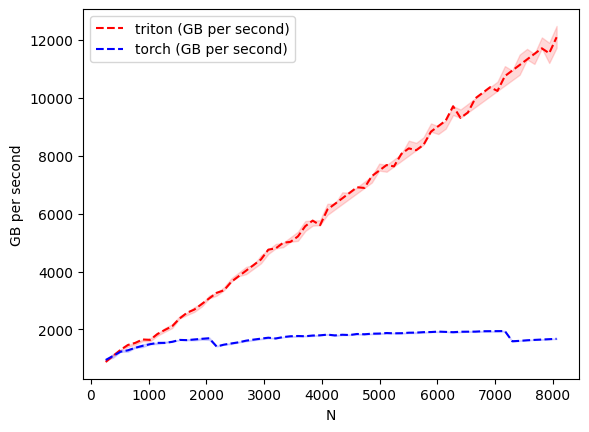

fused-softmax:
         N  triton (GB per second)  torch (GB per second)
0    256.0              877.714274             945.230780
1    384.0             1084.235275            1084.235275
2    512.0             1293.473742            1228.800031
3    640.0             1462.857154            1279.999955
4    768.0             1535.999946            1365.333331
5    896.0             1654.153865            1433.600036
6   1024.0             1638.400041            1489.454534
7   1152.0             1843.200047            1535.999946
8   1280.0             1981.935511            1536.000039
9   1408.0             2112.000005            1571.720930
10  1536.0             2378.322613            1638.399975
11  1664.0             2576.516164            1630.040870
12  1792.0             2688.000007            1654.153865
13  1920.0             2880.000007            1675.636351
14  2048.0             3072.000008            1694.896509
15  2176.0             3264.000008            1411.459398

In [6]:
"""Triton fused softmax with autotuning achieves much higher throughput.
One notable thing with torch is the dip at specific point, which
corresponds with different kernel implementation for different shapes"""

benchmark.run(show_plots=True, print_data=True)